In [1]:
# Esame 654AA - a.a. 2025/2026
# Studenti: Leonardo Celati, Damiano Degliotti, Daniele Melaccio

<h1>CUP — Ensemble OOF</h1>
<p>This notebook combines the most proficient model implemented in their corresponding notebooks:
<ul>
<li>KNN: cup_KNN.ipynb
<li>SVR: cup_SVM.ipynb
<li>NN : cup_NN_manual`</li>
 </ul>
 while LinearSVR and others has been excluded because in the initial test it received zero weight, or they have demonstrated poor performance during model selection phases. The procedure avoids leakage: generates <b>out-of-fold (OOF)</b> predictions with the same folds for all models, optimizes non-negative weights with a sum of 1 compared to the MEE, retrains the models on the entire training set and produces the predictions for the official test set.
</p>
<hr/>

In [2]:
from pathlib import Path
from functools import partial
import copy
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from scipy.optimize import minimize
from sklearn.base import clone
from sklearn.exceptions import ConvergenceWarning
from sklearn.model_selection import KFold
from sklearn.multioutput import MultiOutputRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVR, SVR

import cup_common as cc
import cross_common as cr
import nn_common as nnc

warnings.filterwarnings("ignore", category=ConvergenceWarning)
SEED = 42
N_SPLITS = 5
torch.manual_seed(SEED)
np.random.seed(SEED)

<h2>Preparation</h2>

<h3>Data Loading</h3>

In [3]:
df_train, df_test = cc.load_set()
X_train, y_train = cc.prepare_dataset(df_train)
X_test, _ = cc.prepare_dataset(df_test)
test_ids = df_test["id"].to_numpy()
cr.dataset_introspection(df_train, df_test)

,Property,Training,Test
0,Number of samples,500,1000
1,Number of features,15,11
2,Class values,[],[]
3,Class balance,[],[]


<h3>Hyperparameters</h3>
<p>The configuration below is taken from the latest and most proficient run on their specific models.
</p>
<p>Note: scikit-learn clone the scaler by default at each run</p>

<h4>Scikit-learn configuration</h4>
<p>See the corresponding KNN: cup_KNN.ipynb and SVR: cup_SVM.ipynb notebooks for details about the parameters below.</p>

In [4]:
best_sklearn_grid_params = {
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsRegressor(n_neighbors=3, weights="uniform", p=2)),
    ]),
    "SVR_RBF": Pipeline([
        ("scaler", StandardScaler()),
        ("model", MultiOutputRegressor(SVR(kernel="rbf", C=30, gamma=3, epsilon=0.1))),
    ]),
    # Initially included but then excluded because of zero weight
    # "LinearSVR": Pipeline([
    #     ("scaler", StandardScaler()),
    #     ("model", MultiOutputRegressor(
    #         LinearSVR(C=0.01, dual=False, loss="squared_epsilon_insensitive",
    #                   max_iter=20_000, random_state=SEED)
    #     )),
    # ]),
}

# # Configurazione selezionata in cup_NN_manual.ipynb
# best_NN_hyperparams = {
#     "hidden_layers": [128, 64],
#     "activation": "gelu",
#     "epochs": 1_000,
#     "batch_size": 16,
#     "learning_rate": 0.008206725313798213,
#     "weight_decay": 1.6183611167820987e-05,
# }
#
# def make_nn(seed=SEED):
#     torch.manual_seed(seed)
#     net = nnc.build_nn_net(
#         X_train.shape[1], y_train.shape[1],
#         best_NN_hyperparams["hidden_layers"], best_NN_hyperparams["activation"],
#     )
#     return nnc.build_nn_model(net, nnc.regression_adapter())
#
# def nn_train_params():
#     return {
#         "epochs": best_NN_hyperparams["epochs"],
#         "batch_size": best_NN_hyperparams["batch_size"],
#         "optimizer_template": partial(
#             torch.optim.AdamW, lr=best_NN_hyperparams["learning_rate"],
#             weight_decay=best_NN_hyperparams["weight_decay"], betas=(0.95, 0.999),
#         ),
#         "loss_function": nnc.MEELoss(),
#         "scheduler_template": partial(
#             torch.optim.lr_scheduler.ReduceLROnPlateau, mode="min",
#             threshold_mode="abs", factor=0.5, patience=10, threshold=1e-2,
#         ),
#         "early_stopping_strategy": nnc.EarlyStoppingStrategy(patience=50, min_delta=1e-2),
#         "additional_metrics": {},
#         "silence_output": True,
#     }


<h4>NN Configuration</h4>
<p>See the corresponding NN: cup_NN_manual.ipynb notebook for details about the parameters below.</p>

In [5]:

epochs = 1000
batch_size = 16
learning_rate = 0.008206725313798213 # <-- optuna
weight_decay = 1.6183611167820987e-05 # <-- optuna
hidden_layers = [128, 64]
activation = "gelu"

# The seed to be used by data splitter
default_state = cr.RANDOM_STATE
default_seed = cr.SEED


# The input dimension (i.e. the input layer) is obviously
# the number of feature of the TR set
input_dimension = X_train.shape[1]
output_dimension = 4


# ----- Defining model architecture --------
hidden_layers = hidden_layers
net = nnc.build_nn_net(input_dimension, output_dimension, hidden_layers, activation)

# The output and loss function, must be changed according to the type of task
loss_function = nnc.MEELoss()
output_adapter = nnc.regression_adapter()

# Model implementation
model_template = nnc.build_nn_model(net, output_adapter)
# ------------------------------------------


# -------The weight update algorithm -------
optimizer_template = partial(
    torch.optim.AdamW,
    lr=learning_rate,
    weight_decay=weight_decay,
    betas=(0.95, 0.999)
)
# ------------------------------------------


# ---------- Learning rate decay -----------
# The factor by learning rate will decrease
learning_rate_decay_factor = 0.5
# The epoch to wait before applying the rate decay factor
learning_rate_decay_patience = 10
# The threshold for measuring the new optimum
learning_rate_decay_threshold = 1e-2

# The learning rate decay function
scheduler_template = partial(
    torch.optim.lr_scheduler.ReduceLROnPlateau,
    mode="min", threshold_mode = "abs", factor=learning_rate_decay_factor, patience=learning_rate_decay_patience,
    threshold=learning_rate_decay_threshold
)
# ------------------------------------------


# --------- Early Stopping Strategy --------
early_stopping_patience = 50 # how many epochs to wait before stopping
early_stopping_min_delta = 1e-2 #1e-4 # the treshold or delta to declare an epochs as not improved
early_stopping_strategy = nnc.EarlyStoppingStrategy(patience=early_stopping_patience, min_delta=early_stopping_min_delta)
# ------------------------------------------

nn_train_params = {
    "epochs": epochs,
    "batch_size": batch_size,
    "optimizer_template": optimizer_template,
    "loss_function": loss_function,
    "scheduler_template": scheduler_template,
    "early_stopping_strategy": early_stopping_strategy,
    "silence_output": True,
}


In [6]:
all_model_names = [*best_sklearn_grid_params, "NN"]
print(all_model_names)

['KNN', 'SVR_RBF', 'NN']


<h2>Out-of-fold prediction</h2>

<h3>KFold</h3>
<p>Perform KFold on models by reusing the existing specific KFold function as in cross_common and nn_common.</p>

In [7]:
# fold strategy by defaul returns 5 split with 42 as random seeds
#KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
cv = cr.common_fold_strategy()
metrics = {cr.MEE: (cr.mee, min)}

# OOF predictions holders
oof_predictions = {
    name: np.zeros_like(y_train, dtype=float) for name in all_model_names
}

# Gather all the final scores per model
fold_scores = {name: [] for name in all_model_names}

<h4>Scikit-learn</h4>

In [8]:
# KNN e SVR reuse the same runner and the same cr.kfold of the original notebooks.
sklearn_fold_results = {}
for name, estimator in best_sklearn_grid_params.items():
    runner = cr.SklearnRegressorRunner(estimator)
    results = cr.kfold(runner, X_train, y_train, cv, metrics=metrics)
    sklearn_fold_results[name] = results
    for fold_result in results:
        oof_predictions[name][fold_result.vl_indices] = fold_result.vl_predictions
        fold_scores[name].append(fold_result.fold_vl_mee)

  
Perform fold: 1, train size: 400, val size: 100
 
Fold summary
--------------------------------------------------------------------------------
Validation MEE       | 15.0456
Train                | samples: 400
Validation           | samples: 100
  
Perform fold: 2, train size: 400, val size: 100
 
Fold summary
--------------------------------------------------------------------------------
Validation MEE       | 16.1172
Train                | samples: 400
Validation           | samples: 100
  
Perform fold: 3, train size: 400, val size: 100
 
Fold summary
--------------------------------------------------------------------------------
Validation MEE       | 15.6121
Train                | samples: 400
Validation           | samples: 100
  
Perform fold: 4, train size: 400, val size: 100
 
Fold summary
--------------------------------------------------------------------------------
Validation MEE       | 16.5264
Train                | samples: 400
Validation           | samples: 100


<h4>Neural Network</h4>

In [9]:
# NN reuse the same nnc.kfold of the original notebooks.
model_kf = copy.deepcopy(model_template)
nn_fold_results = nnc.kfold(
    model_kf, X_train, y_train, cv,
    copy.deepcopy(nn_train_params), StandardScaler(),
)

# gathering single fold prediction
for fold_result in nn_fold_results:
    oof_predictions["NN"][fold_result.vl_indices] = fold_result.vl_predictions
    fold_scores["NN"].append(fold_result.fold_vl_loss)

# Train criteria for the final model
nn_training_losses_at_best = [fold_result.fold_tr_loss for fold_result in nn_fold_results]

/Users/leonardo/workspace/library/source/it.unipi.654AA/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Users/leonardo/workspace/library/source/it.unipi.654AA/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Users/leonardo/workspace/library/source/it.unipi.654AA/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Users/leonardo/workspace/library/source/it.unipi.654AA/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Users/leonardo/workspace/library/source/it.unipi.654AA/.venv/lib/python3.14/site-packag

<h4>Scores</h4>

,OOF MEE
KNN,15.743738
SVR_RBF,16.881533
NN,21.178764


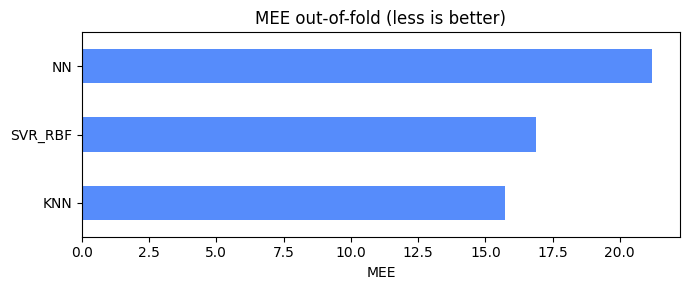

In [10]:
oof_scores = pd.Series(
    {name: cr.mee(y_train, pred) for name, pred in oof_predictions.items()},
    name="OOF MEE",
).sort_values()
display(oof_scores.to_frame())

# Graph score
ax = oof_scores.plot.barh(figsize=(7, 3), title="MEE out-of-fold (less is better)")
ax.set_xlabel("MEE")
plt.tight_layout()
plt.show()

<h4>Weight Optimization</h4>
<p>
The ensemble weights are estimated using the out-of-fold predictions generated during cross-validation. Each weight is constrained to be non-negative, and all weights must sum to one, resulting in a convex combination of the individual model predictions.
</p>
<p>
The optimization minimizes the official project metrics Mean Euclidean Error (MEE) between the true training targets and the blended OOF predictions. Since the official test set is never involved in this process, its target values remain completely unseen during weight selection.
</p>
<p>
A model may receive a small or zero weight when its predictions do not improve the ensemble beyond the contribution of the other models. Therefore, inclusion in the initial pool does not guarantee participation in the final ensemble.
</p>

In [11]:
model_names = list(oof_predictions)
oof_stack = np.stack([oof_predictions[name] for name in model_names], axis=0)

# Compute predictions
def blend_predictions(stack, weights):
    return np.tensordot(weights, stack, axes=(0, 0))

# The objective function to determine weights
def objective(weights):
    return cr.mee(y_train, blend_predictions(oof_stack, weights))

initial_weights = np.full(len(model_names), 1 / len(model_names))
result = minimize(
    objective,
    x0=initial_weights,
    method="SLSQP",
    bounds=[(0.0, 1.0)] * len(model_names),
    constraints={"type": "eq", "fun": lambda w: w.sum() - 1.0},
    options={"maxiter": 2_000, "ftol": 1e-10},
)

if not result.success:
    raise RuntimeError(f"Optimization failed: {result.message}")

weights = result.x / result.x.sum()
weights_table = pd.Series(weights, index=model_names, name="Weight").sort_values(ascending=False)
oof_ensemble = blend_predictions(oof_stack, weights)
display(weights_table.to_frame())
print(f"MEE OOF ensemble: {cr.mee(y_train, oof_ensemble):.4f}")
print(f"Best score:  {oof_scores.min():.4f} ({oof_scores.idxmin()})")

,Weight
KNN,7.115718e-01
SVR_RBF,2.884282e-01
NN,1.467330e-17


MEE OOF ensemble: 15.4447
Best score:  15.7437 (KNN)


<h4>OOF Error Correlation</h4>
<p>
The correlation between the out-of-fold prediction errors of the individual models is analyzed to evaluate their diversity. Models with weakly correlated errors tend to make different mistakes and may therefore complement each other effectively within the ensemble.
</p>
<p>
Conversely, a high positive correlation indicates that two models often make similar errors, reducing the potential benefit of combining their predictions. Error correlation should be considered together with each model's OOF performance, since a diverse but inaccurate model may still provide little or no improvement to the final ensemble.
</p>

In [12]:
# Compute the prediction errors of each model by subtracting
# the OOF predictions from the corresponding true target values.
# The multi-output error matrices are flattened into one-dimensional
# vectors so that correlations can be calculated across all samples
# and target components.
flat_errors = {
    name: (y_train - pred).ravel()
    for name, pred in oof_predictions.items()
}

# Organize the flattened error vectors into a DataFrame, where each
# column represents the OOF errors produced by one model. Then compute
# the pairwise Pearson correlation coefficients between the models.
error_correlation = pd.DataFrame(flat_errors).corr()

# Display the resulting correlation matrix rounded to three decimal
# places for readability.
display(error_correlation.round(3))

,KNN,SVR_RBF,NN
KNN,1.000,0.825,0.672
SVR_RBF,0.825,1.000,0.742
NN,0.672,0.742,1.000


<h3>Final Training and Prediction</h3>
<p>
Each model is retrained on the complete development set of 500 samples using its selected hyperparameters. The fitted models are then used to generate predictions for the official blind test set.
</p>
<p>
Finally, the individual test predictions are combined using the ensemble weights previously estimated from the out-of-fold predictions. This ensures that the official test set is not involved in either model selection or weight optimization.
</p>

In [13]:
# Fitted models holder
fitted_models = {}

# Predictions holder
test_predictions = {}

# ------------ Prediction for scikit-learn models -------------
for name, template in best_sklearn_grid_params.items():
    print(f"Fitted: {name}")
    fitted_models[name] = clone(template).fit(X_train, y_train)
    test_predictions[name] = fitted_models[name].predict(X_test)
# -------------------------------------------------------------


# --------- Predictions for PyTorch NN model ------------------

# Preparing NN data
nn_final_scaler = StandardScaler().fit(X_train)
X_train_nn = pd.DataFrame(nn_final_scaler.transform(X_train), columns=X_train.columns)
X_test_nn = pd.DataFrame(nn_final_scaler.transform(X_test), columns=X_test.columns)

# Creating and retraing a brand new NN using the same criteria used in cup_NN_manual:
# stop training when mean of TR loss media reach best epoch OOF.
nn_target_training_loss = float(np.mean(nn_training_losses_at_best))
torch.manual_seed(SEED)
nn_final = copy.deepcopy(model_template) # It is andatory to clone the NN model
nn_final_params = copy.deepcopy(nn_train_params) # and its parameters as well...
nn_final_params.pop("scheduler_template")
nn_final_params.pop("early_stopping_strategy")
nn_final_params["train_control"] = nn_target_training_loss # <- stop the training
nnc.train(
    nn_final,
    nnc.FullTrainingStrategy(nnc.FeatureTargetSet(X_train_nn, y_train)),
    **nn_final_params,
)
print(f"Fitted: NN")
fitted_models["NN"] = nn_final
test_predictions["NN"] = nn_final.predict(X_test_nn)[0].detach().cpu().numpy()
# -------------------------------------------------------------

# Aggregating results
test_stack = np.stack([test_predictions[name] for name in model_names], axis=0)
y_pred_ensemble = blend_predictions(test_stack, weights)
assert y_pred_ensemble.shape == (len(X_test), 4)
y_pred_ensemble[:5]

Fitted: KNN
Fitted: SVR_RBF
Fitted: NN


array([[ -2.55445996,  -1.66261265,   6.20809509,  -6.30951286],
       [ -9.72793809,  -3.55605805, -48.01756373,   5.82690478],
       [ -2.27476978,  -2.71844776,  -3.45489491,   6.03522295],
       [ -5.89667872,  12.06004384, -29.55381336,   7.5177518 ],
       [  3.0987032 ,  -7.97005003, -22.55813717,  20.68498833]])

<h4>CUP Submission File</h4>
<p>The cell below generates the final blind-test file in the ML-CUP submission format.</p>

In [14]:
TEAM_NICKNAME = "celati_degliotti_melaccio"
TEAM_MEMBERS = "Leonardo Celati, Damiano Degliotti, Daniele Melaccio"
SUBMISSION_DATE = "2026-08-15"

output_dir = Path("ensemble_outputs")
output_dir.mkdir(exist_ok=True)
cup_path = output_dir / f"{TEAM_NICKNAME}_ML-CUP25-TS.csv"

submission = pd.DataFrame(y_pred_ensemble)
submission.insert(0, "id", test_ids.astype(int))

cup_header = [
    "# ML-CUP25",
    f"# {TEAM_NICKNAME}",
    f"# {TEAM_MEMBERS}",
    f"# {SUBMISSION_DATE}",
]
with cup_path.open("w", encoding="utf-8", newline="") as cup_file:
    cup_file.write("\n".join(cup_header) + "\n")
    submission.to_csv(cup_file, index=False, header=False)

assert submission.shape == (len(X_test), 5)
assert submission["id"].tolist() == test_ids.astype(int).tolist()
display(submission.head())
print(f"CUP submission saved to: {cup_path.resolve()}")

,id,0,1,2,3
0,1,-2.554460,-1.662613,6.208095,-6.309513
1,2,-9.727938,-3.556058,-48.017564,5.826905
2,3,-2.274770,-2.718448,-3.454895,6.035223
3,4,-5.896679,12.060044,-29.553813,7.517752
4,5,3.098703,-7.970050,-22.558137,20.684988


CUP submission saved to: /Users/leonardo/workspace/library/source/it.unipi.654AA/notebooks/ensemble_outputs/celati_degliotti_melaccio_ML-CUP25-TS.csv


## Note

- Se l'ensemble OOF non supera il miglior modello singolo, usa il miglior modello singolo: l'ensemble non è automaticamente migliore.
- La rete neurale usa la configurazione di `cup_NN_manual.ipynb` e viene reinizializzata in ogni fold.
- Per una stima più rigorosa delle prestazioni dell'intera procedura di scelta dei pesi servirebbe una cross-validation esterna; questa versione è pensata per costruire l'ensemble finale in modo semplice e riproducibile.